# Figuras del TFM · 40 diagramas en 10 láminas

Veinte páginas para toda la memoria obligan a una aritmética sencilla: **una figura por página
es inviable**. La solución no es recortar el análisis a cuatro gráficos, sino agrupar: cada
lámina reúne cuatro diagramas que cuentan una historia, ocupa una página y lleva un pie que la
lee como conjunto.

Diez láminas = diez páginas de figuras y diez de texto. Con cuarenta diagramas dentro.

## Cómo están elegidas

Cada lámina responde a **una pregunta**, y sus cuatro paneles la responden desde ángulos que no
se solapan. Si dos paneles dicen lo mismo, uno sobra. El orden de las láminas es el del
razonamiento del proyecto:

| Lámina | Pregunta | Paneles |
|---|---|---|
| **L1** | ¿Cómo es lo que hay que predecir? | 1-4 |
| **L2** | ¿Qué estructura temporal tiene? | 5-8 |
| **L3** | ¿Cuánto se explica a sí mismo? | 9-12 |
| **L4** | ¿Cómo se forma el precio? | 13-16 |
| **L5** | ¿Qué lo explica, y qué de eso se puede usar? | 17-20 |
| **L6** | ¿Sirve para decidir cuándo operar? | 21-24 |
| **L7** | ¿Cómo de buenas son las entradas disponibles? | 25-28 |
| **L8** | ¿Son fiables los datos de partida? | 29-32 |
| **L9** | ¿Qué fuente se elige cuando hay dos? | 33-36 |
| **L10** | ¿Contra qué se compara el modelo? | 37-40 |

Las láminas **L1, L5, L7 y L10** son las imprescindibles si hubiera que bajar de diez: el
problema, la frontera de fuga, el suelo de error heredado y el listón económico.

## Notas de método

**Cada panel se guarda también suelto**, por si alguno acaba mereciendo página propia o se
necesita para la defensa. La lámina es la unidad de publicación; el panel, la de trabajo.

**Estilo declarado una vez.** Paleta, tipografías y mapas de color viven en el bloque 0. Cambiar
el color de "con fuga" ahí lo cambia en las cuarenta.

**Si un panel falla, se marca en su hueco** en lugar de tumbar la lámina. Es preferible una
lámina con un aviso a no tener lámina.

---
## 0 · Estilo, carga y utilidades

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

%matplotlib inline
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*PeriodArray.*")

RAIZ = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
SALIDA = RAIZ / "docs" / "figuras"
SUELTOS = SALIDA / "paneles"
TZ = "Europe/Madrid"

APAGON = (pd.Timestamp("2025-04-28", tz="UTC"), pd.Timestamp("2025-05-06 23:00", tz="UTC"))
EXCEPCION = (pd.Timestamp("2022-06-15", tz="UTC"), pd.Timestamp("2023-12-31 23:00", tz="UTC"))

PALETA = {"principal": "#1f4e79", "secundario": "#2b7bba", "acento": "#f5a623",
          "alerta": "#c0392b", "ok": "#2ca02c", "neutro": "#7f7f7f", "suave": "#d9d9d9"}
COLOR_FUGA = {"SIN FUGA": PALETA["ok"], "DESFASE D-2": PALETA["acento"],
              "CON FUGA": PALETA["alerta"], "CONDICIONAL": PALETA["neutro"],
              "TARGET": "#000000"}
CMAP_DIV, CMAP_SEQ, CMAP_CAL = "RdBu_r", "viridis", "YlOrRd"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 8.5, "axes.titlesize": 9.5, "axes.labelsize": 8.5,
    "legend.fontsize": 7.5, "xtick.labelsize": 7.5, "ytick.labelsize": 7.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "figure.facecolor": "white",
    "axes.prop_cycle": plt.cycler(color=[PALETA["principal"], PALETA["acento"],
                                         PALETA["ok"], PALETA["alerta"],
                                         PALETA["secundario"], PALETA["neutro"]]),
})

LAMINAS = []          # (etiqueta, fichero, título, pie)
PANELES_OK = []       # nombres de los paneles que salieron bien

def pick(d, *c):
    for x in c:
        if x is not None and x in d.columns:
            return x
    return None

def sin_rejilla(ax):
    ax.grid(False)
    return ax

In [2]:
df = pd.read_parquet(RAIZ / "data" / "bronze" / "bronze_unificado.parquet")
df["ts_utc"] = pd.to_datetime(df["ts_utc"], utc=True)
assert df["ts_utc"].duplicated().sum() == 0, "parquet duplicado: regenerar con union_bronze"

df["ts_local"] = df["ts_utc"].dt.tz_convert(TZ)
df["hora"] = df["ts_local"].dt.hour
df["dia"] = df["ts_local"].dt.date
df["anio"] = df["ts_local"].dt.year
df["mes"] = df["ts_local"].dt.month
df["dow"] = df["ts_local"].dt.dayofweek
df["mes_p"] = df["ts_local"].dt.to_period("M")
df["regimen"] = np.select(
    [df["ts_utc"].between(*APAGON), df["ts_utc"].between(*EXCEPCION)],
    ["apagón", "excepción ibérica"], default="normal")

P = pick(df, "spot_es_esios", "spot_es_omie", "spot_es_entsoe")
if P is None:
    raise SystemExit("Falta spot_price en el bronce: sin target no hay memoria que escribir.")

# Columnas resueltas una sola vez. Cada driver lleva su etiqueta de fuga pegada.
D = {k: v for k, v in {
    "demanda prevista": (pick(df, "forecast_demanda_mercado_prev_mw"), "SIN FUGA"),
    "eólica prevista":  (pick(df, "forecast_gen_wind_prev_mw"), "SIN FUGA"),
    "solar prevista":   (pick(df, "forecast_gen_solar_pv_prev_mw"), "SIN FUGA"),
    "gas":              (pick(df, "tp_ttf_cierre", "commodities_gas_ttf_m1"), "DESFASE D-2"),
    "CO2":              (pick(df, "tp_eua_cierre", "commodities_co2_eua_dec"), "DESFASE D-2"),
    "demanda real":     (pick(df, "load_inter_entsoe_load"), "CON FUGA"),
    "eólica real":      (pick(df, "entsoe_wind_mw"), "CON FUGA"),
    "solar FV real":    (pick(df, "calc_solar_fv_mw"), "CON FUGA"),
    "hidráulica":       (pick(df, "calc_hydro_dispatch_mw"), "CON FUGA"),
    "ciclo combinado":  (pick(df, "esios_gen_ree_gccgas_mw"), "CON FUGA"),
    "temperatura":      (pick(df, "era5_t2m_mean"), "CON FUGA"),
}.items() if v[0]}

DEM, EOL, FV = pick(df, "load_inter_entsoe_load"), pick(df, "entsoe_wind_mw"), pick(df, "calc_solar_fv_mw")
GAS = pick(df, "tp_ttf_cierre", "commodities_gas_ttf_m1")
NORMAL = df[df["regimen"] == "normal"]

# Clases de hora para el BESS: las K más caras y las K más baratas de CADA día.
K = 4
cl = df[["dia", "hora", "anio", P]].dropna(subset=[P]).copy()
cl["rango"] = cl.groupby("dia")[P].rank(method="first")
cl["n"] = cl.groupby("dia")[P].transform("size")
cl["clase"] = "intermedia"
cl.loc[cl["rango"] <= K, "clase"] = "barata"
cl.loc[cl["rango"] > cl["n"] - K, "clase"] = "cara"
cl["es_cara"] = (cl["clase"] == "cara").astype(int)
CL = cl.merge(df[["dia", "hora"] + [c for c, _ in D.values()]], on=["dia", "hora"], how="left")

print(f"{len(df):,} horas · target {P} · {len(D)} drivers · {len(NORMAL):,} horas en régimen normal")

58,319 horas · target spot_es_esios · 11 drivers · 44,543 horas en régimen normal


### 0.1 · El compositor de láminas

`lamina()` recibe cuatro paneles —cada uno una función que dibuja en un eje— y los compone. Si
uno falla, escribe el aviso en su hueco y sigue: es preferible una lámina con tres paneles
buenos y una nota que ninguna lámina.

`panel_suelto()` regenera cualquiera por separado, para cuando uno merezca página propia.

In [3]:
def lamina(etq, titulo, pie, paneles, ncol=2, alto=3.3):
    '''Compone 4 paneles en una figura de página. Cada panel es (subtítulo, función(ax)).'''
    SALIDA.mkdir(parents=True, exist_ok=True)
    nfil = int(np.ceil(len(paneles) / ncol))
    fig, axes = plt.subplots(nfil, ncol, figsize=(6.4 * ncol, alto * nfil))
    ejes = np.atleast_1d(axes).ravel()
    for ax, (sub, fn) in zip(ejes, paneles):
        try:
            fn(ax)
            ax.set_title(sub, fontsize=9.5)
            PANELES_OK.append(sub)
        except Exception as e:
            ax.clear(); ax.axis("off")
            ax.text(0.5, 0.5, f"{sub}\n\nno disponible\n({type(e).__name__}: {e})",
                    ha="center", va="center", fontsize=7.5, color=PALETA["neutro"], wrap=True)
    for ax in ejes[len(paneles):]:
        ax.axis("off")
    fig.suptitle(titulo, fontsize=11.5, y=1.003)
    plt.tight_layout()
    ruta = SALIDA / f"{etq}.png"
    fig.savefig(ruta)
    LAMINAS.append((etq, ruta.name, titulo, pie))
    print(f"  {etq}  {ruta.name}")
    plt.show(); plt.close(fig)


def panel_suelto(nombre, fn, figsize=(7, 4)):
    '''Regenera un panel por separado, por si merece página propia.'''
    SUELTOS.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=figsize)
    fn(ax)
    plt.tight_layout()
    fig.savefig(SUELTOS / f"{nombre}.png")
    plt.show(); plt.close(fig)

---
# Lámina 1 · ¿Cómo es lo que hay que predecir?

**Paneles 1-4.** La serie sitúa el nivel y marca los dos períodos que son otro proceso. El
histograma en escala logarítmica enseña unas colas que una escala lineal esconde. El reparto por
rango revela que los precios negativos **aparecen de la nada** a mitad del histórico. Y la curva
de duración resume cada año en una línea: cuántas horas superan cualquier precio dado.

Juntos dicen algo incómodo: **el problema cambió de naturaleza durante el propio período de
entrenamiento**.

  L01_target  L01_target.png


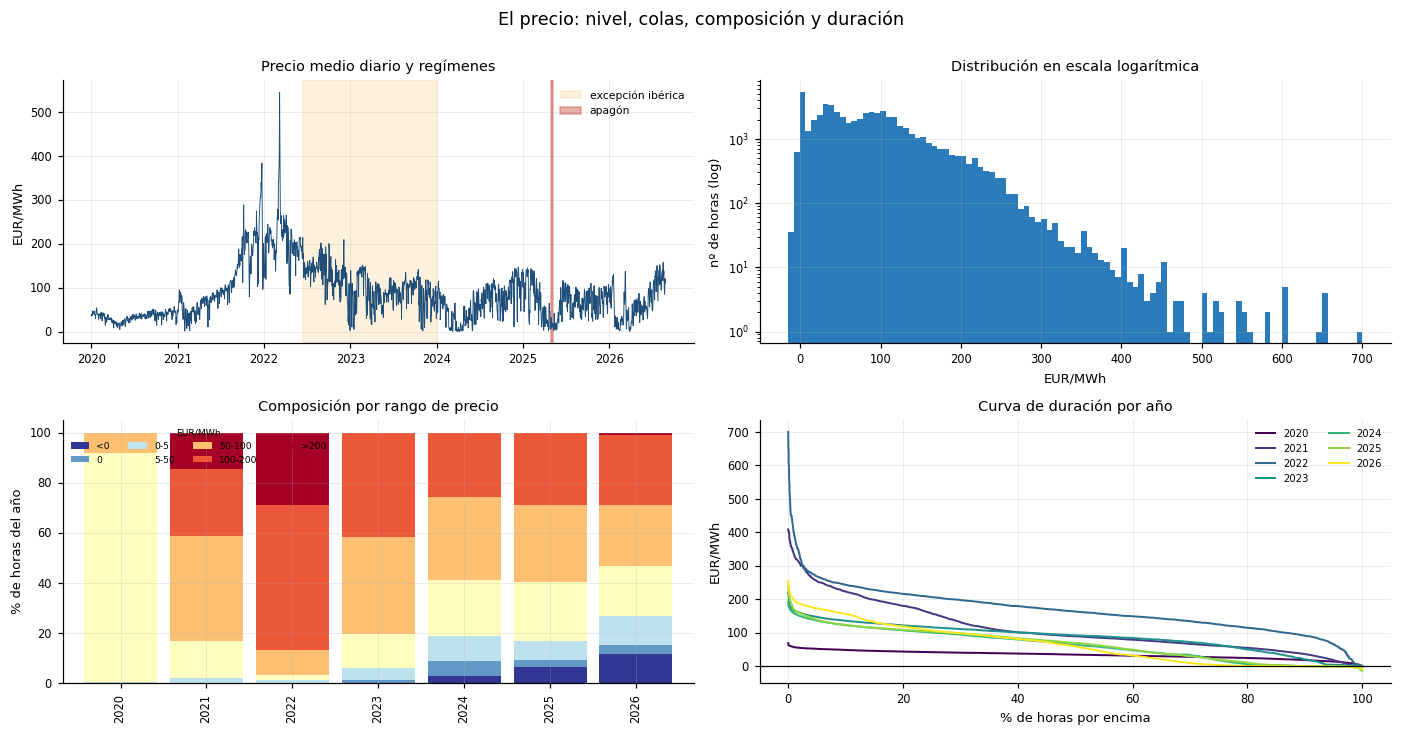

In [4]:
def p01(ax):
    s = df.groupby("dia")[P].mean()
    ax.plot(pd.to_datetime(s.index), s.values, lw=0.6, color=PALETA["principal"])
    ax.axvspan(EXCEPCION[0].tz_localize(None), EXCEPCION[1].tz_localize(None),
               alpha=0.15, color=PALETA["acento"], label="excepción ibérica")
    ax.axvspan(APAGON[0].tz_localize(None), APAGON[1].tz_localize(None),
               alpha=0.40, color=PALETA["alerta"], label="apagón")
    ax.set_ylabel("EUR/MWh"); ax.legend(frameon=False, fontsize=7)

def p02(ax):
    ax.hist(df[P].dropna(), bins=100, color=PALETA["secundario"])
    ax.set_yscale("log"); ax.set_xlabel("EUR/MWh"); ax.set_ylabel("nº de horas (log)")

def p03(ax):
    bins = [-np.inf, 0, 0.001, 5, 50, 100, 200, np.inf]
    etq = ["<0", "0", "0-5", "5-50", "50-100", "100-200", ">200"]
    t = pd.crosstab(df["anio"], pd.cut(df[P], bins=bins, labels=etq, right=False))
    (t.div(t.sum(axis=1), axis=0) * 100).plot(kind="bar", stacked=True, ax=ax,
                                              width=0.85, colormap="RdYlBu_r", legend=False)
    ax.set_ylabel("% de horas del año"); ax.set_xlabel("")
    ax.legend(frameon=False, fontsize=6, ncol=4, title="EUR/MWh", title_fontsize=6)

def p04(ax):
    cmap = plt.get_cmap(CMAP_SEQ); aa = sorted(df["anio"].unique())
    for i, a in enumerate(aa):
        s = df.loc[df["anio"] == a, P].dropna().sort_values(ascending=False).values
        ax.plot(np.linspace(0, 100, len(s)), s, lw=1.3,
                color=cmap(i / max(len(aa) - 1, 1)), label=str(a))
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("% de horas por encima"); ax.set_ylabel("EUR/MWh")
    ax.legend(frameon=False, ncol=2, fontsize=6.5)

lamina("L01_target", "El precio: nivel, colas, composición y duración",
       "Cuatro vistas del target. La escala logarítmica del segundo panel revela unas colas que "
       "la lineal esconde; el tercero muestra que los precios negativos aparecen a mitad del "
       "histórico y crecen cada año. El problema cambió de naturaleza durante el propio "
       "período de entrenamiento, lo que condiciona cómo se pondera el histórico.",
       [("Precio medio diario y regímenes", p01),
        ("Distribución en escala logarítmica", p02),
        ("Composición por rango de precio", p03),
        ("Curva de duración por año", p04)])

---
# Lámina 2 · ¿Qué estructura temporal tiene?

**Paneles 5-8.** El perfil horario por año es el panel que más pesa de toda la memoria: la hora
del mínimo se desplaza y la amplitud crece. Los dos mapas de calor separan las estacionalidades
—anual y semanal— y enseñan su interacción. Los violines añaden la forma completa: las horas
centrales no solo tienen media más baja, tienen otra distribución.

  L02_estructura_temporal  L02_estructura_temporal.png


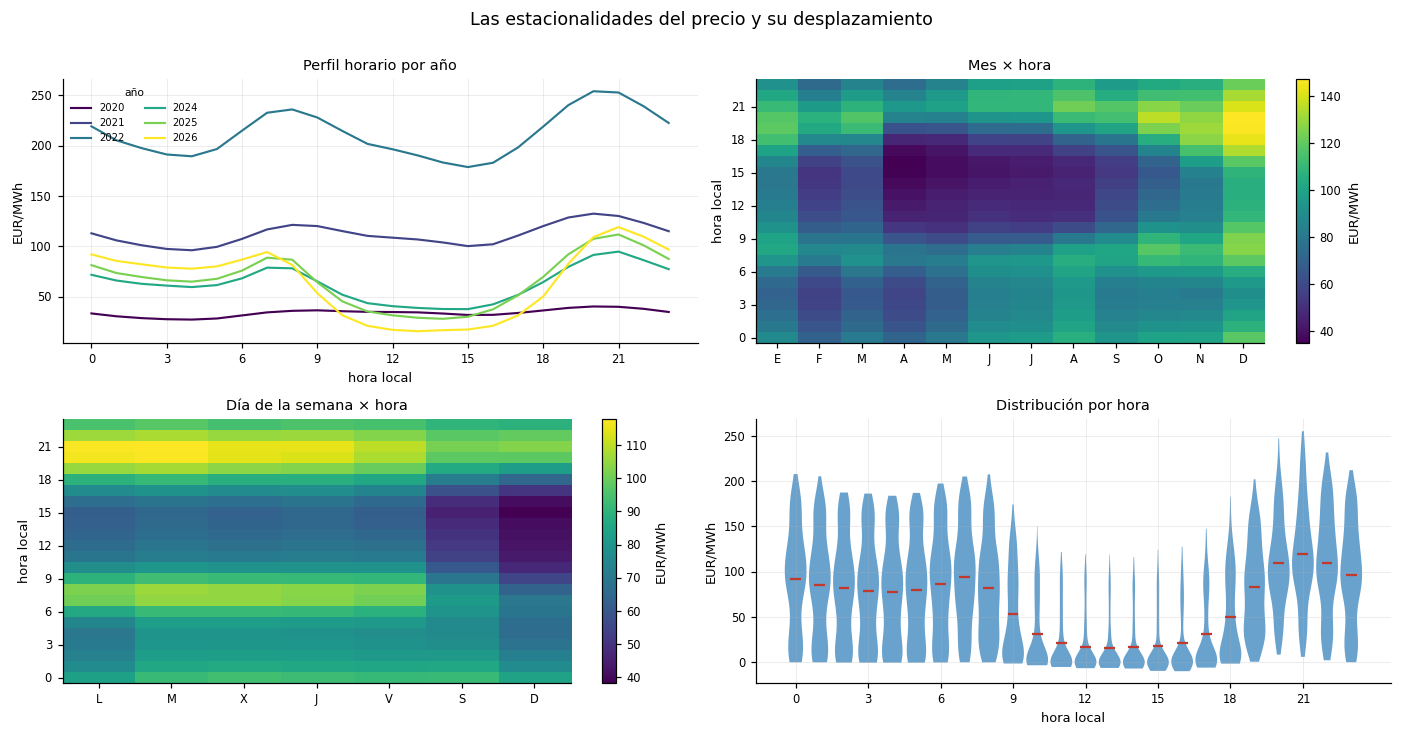

In [5]:
def p05(ax):
    pv = NORMAL.pivot_table(index="hora", columns="anio", values=P, aggfunc="mean")
    pv.plot(ax=ax, lw=1.4, colormap=CMAP_SEQ)
    ax.set_xlabel("hora local"); ax.set_ylabel("EUR/MWh"); ax.set_xticks(range(0, 24, 3))
    ax.legend(title="año", frameon=False, ncol=2, fontsize=6.5, title_fontsize=7)

def p06(ax):
    h = NORMAL.pivot_table(index="hora", columns="mes", values=P, aggfunc="mean")
    im = ax.imshow(h.values, aspect="auto", origin="lower", cmap=CMAP_SEQ)
    ax.set_xticks(range(12), list("EFMAMJJASOND")); ax.set_yticks(range(0, 24, 3))
    ax.set_ylabel("hora local"); sin_rejilla(ax)
    plt.colorbar(im, ax=ax, label="EUR/MWh")

def p07(ax):
    h = NORMAL.pivot_table(index="hora", columns="dow", values=P, aggfunc="mean")
    im = ax.imshow(h.values, aspect="auto", origin="lower", cmap=CMAP_SEQ)
    ax.set_xticks(range(7), ["L", "M", "X", "J", "V", "S", "D"])
    ax.set_yticks(range(0, 24, 3)); ax.set_ylabel("hora local"); sin_rejilla(ax)
    plt.colorbar(im, ax=ax, label="EUR/MWh")

def p08(ax):
    ult = NORMAL[NORMAL["anio"] == NORMAL["anio"].max()]
    if len(ult) < 2000:
        ult = NORMAL
    datos = [ult.loc[ult["hora"] == h, P].dropna().values for h in range(24)]
    datos = [d if len(d) > 10 else np.array([np.nan]) for d in datos]
    vp = ax.violinplot(datos, positions=range(24), widths=0.9, showmeans=True, showextrema=False)
    for c in vp["bodies"]:
        c.set_facecolor(PALETA["secundario"]); c.set_alpha(0.7)
    vp["cmeans"].set_color(PALETA["alerta"])
    ax.set_xticks(range(0, 24, 3)); ax.set_xlabel("hora local"); ax.set_ylabel("EUR/MWh")

lamina("L02_estructura_temporal", "Las estacionalidades del precio y su desplazamiento",
       "El perfil horario por año (arriba izquierda) es el resultado central del análisis: la "
       "hora del mínimo se desplaza hacia el mediodía y la amplitud entre máximo y mínimo se "
       "multiplica. Los mapas de calor separan el ciclo anual del semanal, y los violines "
       "añaden la forma completa de la distribución en cada hora.",
       [("Perfil horario por año", p05), ("Mes × hora", p06),
        ("Día de la semana × hora", p07), ("Distribución por hora", p08)])

---
# Lámina 3 · ¿Cuánto se explica el precio a sí mismo?

**Paneles 9-12.** Antes de buscar variables externas hay que saber cuánto explica el propio
pasado. Si el precio de ayer ya da la mayor parte, **cualquier feature exógena tiene que aportar
por encima de eso**.

Los dos primeros paneles son ACF y PACF, las funciones canónicas del análisis de series. El
tercero muestra la autocorrelación horaria hasta ocho días, donde los picos de 24 h se ven a
simple vista. El cuarto introduce el diferencial diario, que es lo que aprovecha la batería.

  L03_persistencia  L03_persistencia.png


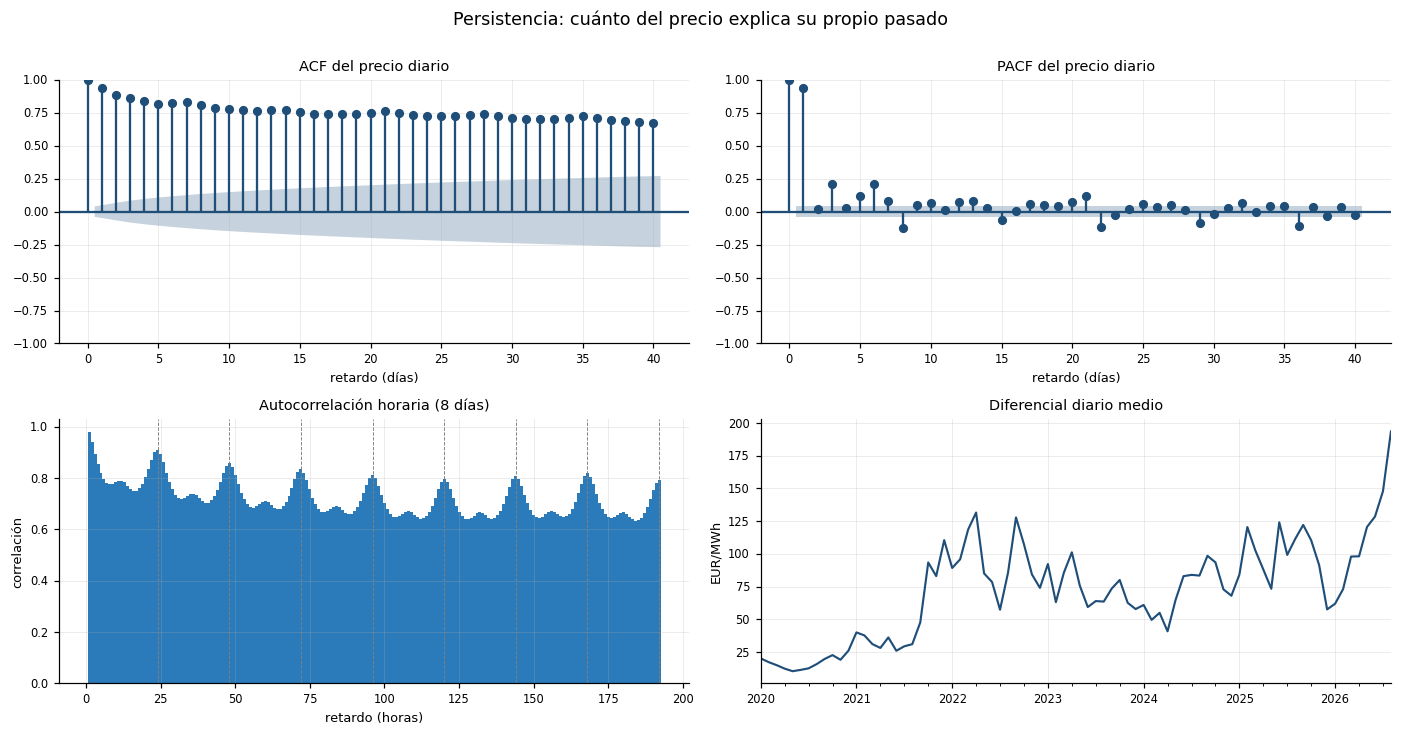

In [6]:
_diario = df.groupby("dia")[P].mean()
_diario.index = pd.to_datetime(_diario.index)
_diario = _diario.asfreq("D").interpolate(limit=3)

def p09(ax):
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(_diario.dropna(), lags=40, ax=ax)
    ax.set_xlabel("retardo (días)"); ax.set_title("")

def p10(ax):
    from statsmodels.graphics.tsaplots import plot_pacf
    plot_pacf(_diario.dropna(), lags=40, ax=ax, method="ywm")
    ax.set_xlabel("retardo (días)"); ax.set_title("")

def p11(ax):
    s = df.set_index("ts_utc")[P].asfreq("h")
    ax.bar(range(1, 193), [s.corr(s.shift(k)) for k in range(1, 193)],
           width=1.0, color=PALETA["secundario"])
    for k in range(24, 193, 24):
        ax.axvline(k, color=PALETA["neutro"], lw=0.6, ls="--")
    ax.set_xlabel("retardo (horas)"); ax.set_ylabel("correlación")

def p12(ax):
    sp = df.groupby("dia")[P].agg(["min", "max"])
    sp.index = pd.to_datetime(sp.index)
    (sp["max"] - sp["min"]).resample("MS").mean().plot(ax=ax, lw=1.4,
                                                       color=PALETA["principal"])
    ax.set_ylabel("EUR/MWh"); ax.set_xlabel("")

lamina("L03_persistencia", "Persistencia: cuánto del precio explica su propio pasado",
       "Funciones de autocorrelación total y parcial del precio diario, autocorrelación horaria "
       "hasta ocho días —donde los múltiplos de 24 h destacan— y evolución del diferencial "
       "diario. La persistencia fija la vara mínima: una feature exógena sólo se justifica si "
       "aporta por encima de lo que ya da el precio de ayer.",
       [("ACF del precio diario", p09), ("PACF del precio diario", p10),
        ("Autocorrelación horaria (8 días)", p11), ("Diferencial diario medio", p12)])

---
# Lámina 4 · ¿Cómo se forma el precio?

**Paneles 13-16.** Es la lámina que explica el mecanismo. La curva de oferta empírica dibuja el
orden de mérito deducido del dato: cuánto cuesta cubrir cada nivel de demanda residual, y **cómo
se desplaza esa curva** conforme cambia el parque.

Los dos paneles del gas muestran el desacople de la excepción ibérica. El último cuenta cuándo
ocurren las horas de precio nulo o negativo, que es donde el almacenamiento gana dinero.

  L04_formacion_precio  L04_formacion_precio.png


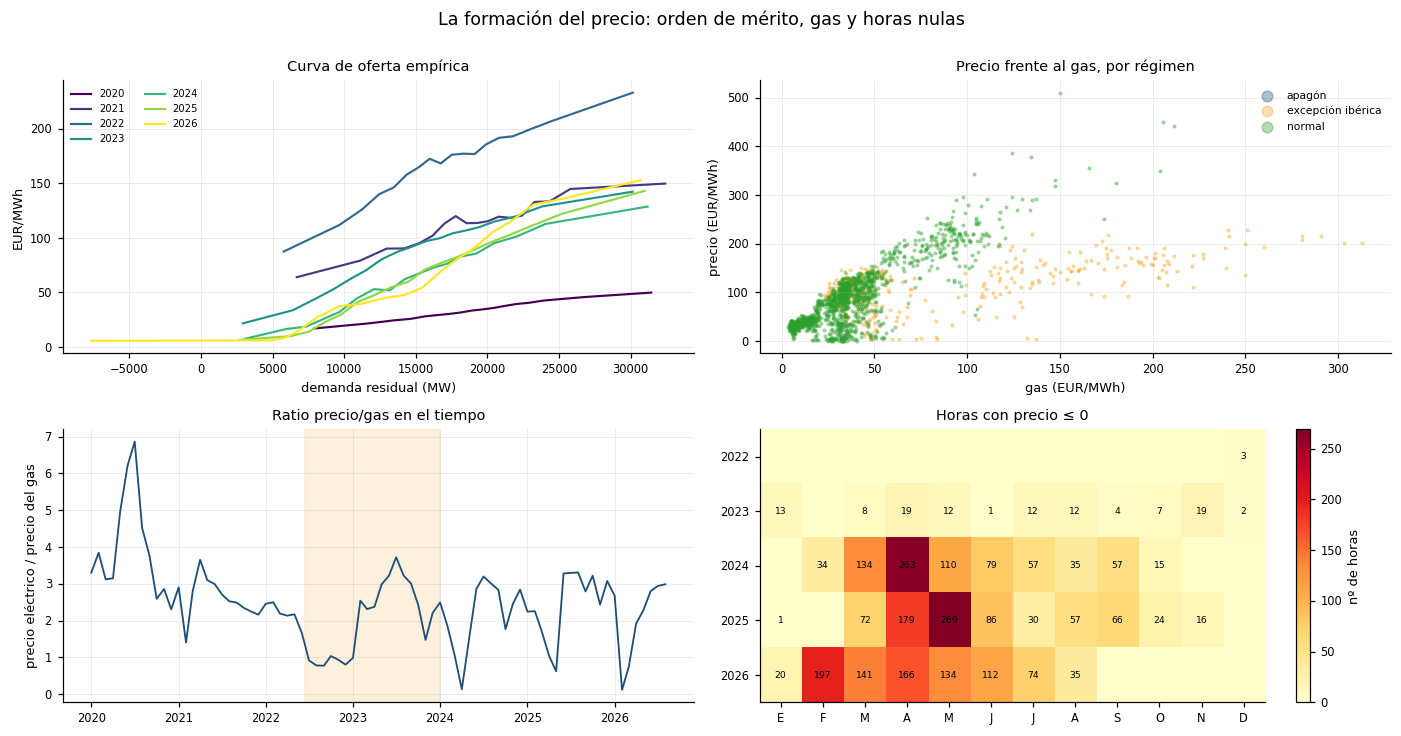

In [7]:
def p13(ax):
    if not all([DEM, EOL, FV]):
        raise ValueError("faltan columnas de demanda o renovable")
    r = df[["anio", P, DEM, EOL, FV]].dropna().copy()
    r["residual"] = r[DEM] - r[EOL] - r[FV]
    cmap = plt.get_cmap(CMAP_SEQ); aa = sorted(r["anio"].unique())
    for i, a in enumerate(aa):
        sub = r[r["anio"] == a]
        tr = pd.qcut(sub["residual"], 18, duplicates="drop")
        pf = sub.groupby(tr, observed=True)[P].mean()
        ax.plot([iv.mid for iv in pf.index], pf.values, lw=1.4,
                color=cmap(i / max(len(aa) - 1, 1)), label=str(a))
    ax.set_xlabel("demanda residual (MW)"); ax.set_ylabel("EUR/MWh")
    ax.legend(frameon=False, ncol=2, fontsize=6.5)

def p14(ax):
    if not GAS:
        raise ValueError("sin columna de gas")
    d = df[["regimen", P, GAS]].dropna()
    for r, sub in d.groupby("regimen"):
        ax.scatter(sub[GAS], sub[P], s=3, alpha=0.35, label=r)
    ax.set_xlabel("gas (EUR/MWh)"); ax.set_ylabel("precio (EUR/MWh)")
    ax.legend(frameon=False, markerscale=4, fontsize=7)

def p15(ax):
    if not GAS:
        raise ValueError("sin columna de gas")
    d = df[["mes_p", "regimen", P, GAS]].dropna()
    ratio = (d[P] / d[GAS].replace(0, np.nan)).groupby(d["mes_p"]).median()
    ax.plot(ratio.index.to_timestamp(), ratio.values, lw=1.2, color=PALETA["principal"])
    ax.axvspan(EXCEPCION[0].tz_localize(None), EXCEPCION[1].tz_localize(None),
               alpha=0.15, color=PALETA["acento"])
    ax.set_ylabel("precio eléctrico / precio del gas"); ax.set_xlabel("")

def p16(ax):
    cero = df[df[P] <= 0]
    t = cero.pivot_table(index="anio", columns="mes", values=P, aggfunc="size")
    t = t.reindex(columns=range(1, 13)).fillna(0)
    im = ax.imshow(t.values, aspect="auto", cmap=CMAP_CAL)
    ax.set_xticks(range(12), list("EFMAMJJASOND"))
    ax.set_yticks(range(len(t)), t.index)
    for i in range(t.shape[0]):
        for j in range(t.shape[1]):
            if t.iloc[i, j] > 0:
                ax.text(j, i, f"{int(t.iloc[i, j])}", ha="center", va="center", fontsize=6)
    sin_rejilla(ax); plt.colorbar(im, ax=ax, label="nº de horas")

lamina("L04_formacion_precio", "La formación del precio: orden de mérito, gas y horas nulas",
       "La curva de oferta empírica (arriba izquierda) es el orden de mérito deducido del dato: "
       "su desplazamiento entre años mide el cambio del parque de generación. Los paneles del "
       "gas muestran el desacople provocado por el tope, y el último localiza en el calendario "
       "las horas de precio nulo o negativo.",
       [("Curva de oferta empírica", p13), ("Precio frente al gas, por régimen", p14),
        ("Ratio precio/gas en el tiempo", p15), ("Horas con precio ≤ 0", p16)])

---
# Lámina 5 · ¿Qué explica el precio, y qué de eso se puede usar?

**Paneles 17-20.** La lámina central del argumento. El ranking de correlación va **coloreado por
disponibilidad**: verde si el dato existe a las 12:00 de D, rojo si no. Casi todo lo que
encabeza está en rojo.

Los otros tres paneles matizan esa correlación única: cómo cambia según la hora, si se sostiene
año a año, y cuánto se pierde al suponer linealidad.

c:\Users\torgi\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\torgi\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  L05_drivers_fuga  L05_drivers_fuga.png


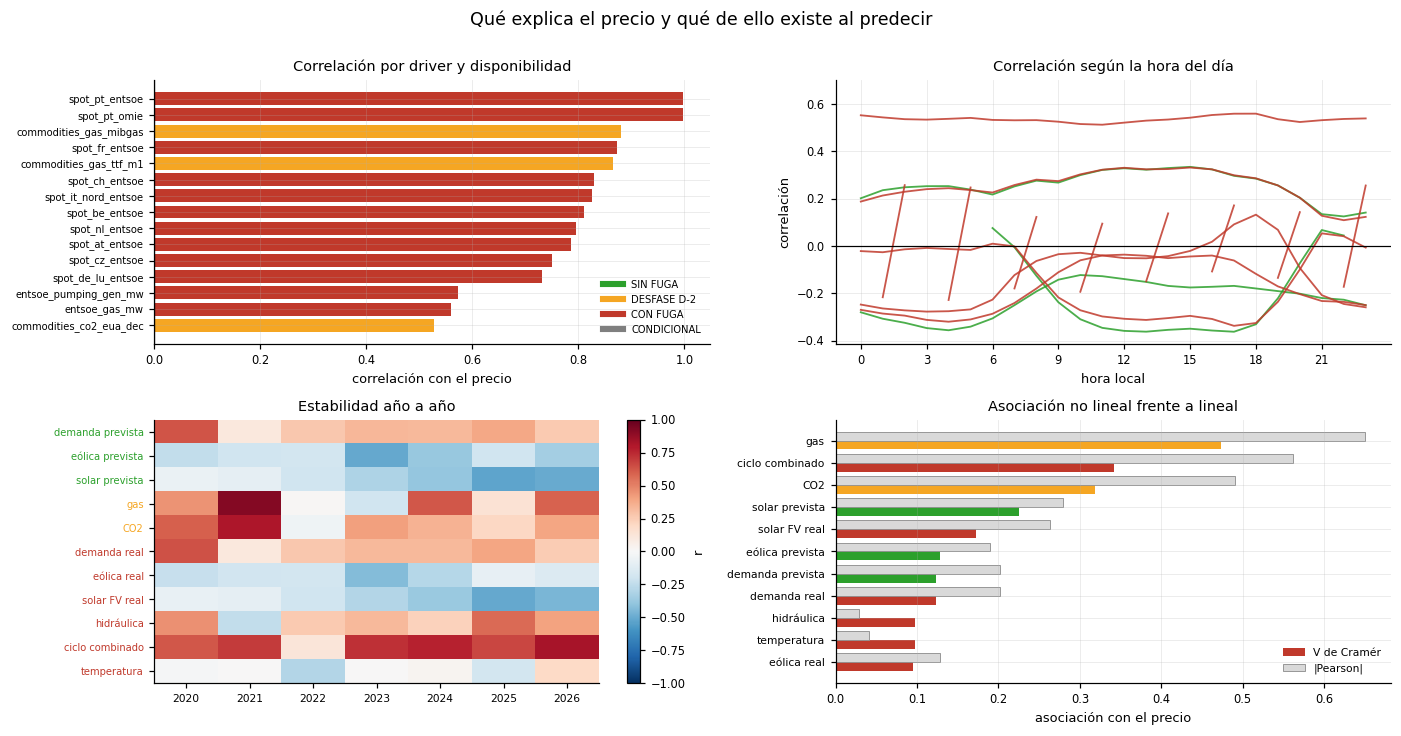

In [8]:
ETQ = [("forecast_", "SIN FUGA"), ("fc_", "SIN FUGA"), ("ent_fc_", "SIN FUGA"),
       ("tp_", "DESFASE D-2"), ("commodities_", "DESFASE D-2"), ("era5_", "CON FUGA"),
       ("entsoe_", "CON FUGA"), ("esios_gen_", "CON FUGA"), ("load_inter_", "CON FUGA"),
       ("gen_", "CON FUGA"), ("calc_", "CON FUGA"), ("cap_disp_", "CONDICIONAL"),
       ("cap_inst_", "SIN FUGA"), ("spot_", "CON FUGA")]

def fuga_de(c):
    if c == P:
        return "TARGET"
    for pre, v in ETQ:
        if c.startswith(pre):
            return v
    return "CONDICIONAL"

def p17(ax):
    num = [c for c in df.select_dtypes(include=[np.number]).columns
           if c not in ("hora", "anio", "mes", "dow", "hour_utc", "hour_local", "tensor_index")]
    # Las otras fuentes españolas son EL MISMO target: incluirlas sería tautológico.
    num = [c for c in num if c not in {"spot_es_esios", "spot_es_omie", "spot_es_entsoe"} - {P}]
    r = NORMAL[num].corr()[P].drop(P, errors="ignore").dropna()
    r = r.reindex(r.abs().sort_values(ascending=False).index).head(15)
    fugas = [fuga_de(c) for c in r.index]
    ax.barh(range(len(r)), r.values[::-1],
            color=[COLOR_FUGA.get(f, PALETA["neutro"]) for f in fugas[::-1]])
    ax.set_yticks(range(len(r)), [c[:34] for c in r.index[::-1]], fontsize=6.5)
    ax.axvline(0, color="black", lw=0.8); ax.set_xlabel("correlación con el precio")
    ax.legend(handles=[Line2D([0], [0], color=v, lw=4, label=k)
                       for k, v in COLOR_FUGA.items() if k != "TARGET"],
              frameon=False, fontsize=6.5, loc="lower right")

def p18(ax):
    ph = pd.DataFrame({k: df.groupby("hora").apply(lambda g: g[P].corr(g[v[0]]),
                                                   include_groups=False)
                       for k, v in D.items()})
    for c in ph.columns:
        ax.plot(ph.index, ph[c], lw=1.2, color=COLOR_FUGA.get(D[c][1], PALETA["neutro"]),
                alpha=0.85)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("hora local"); ax.set_ylabel("correlación"); ax.set_xticks(range(0, 24, 3))

def p19(ax):
    E = pd.DataFrame([df.groupby("anio").apply(lambda g: g[P].corr(g[v[0]]),
                                               include_groups=False).rename(k)
                      for k, v in D.items()])
    im = ax.imshow(E.values, cmap=CMAP_DIV, norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1),
                   aspect="auto")
    ax.set_xticks(range(E.shape[1]), E.columns, fontsize=7)
    ax.set_yticks(range(len(E)), E.index, fontsize=6.5)
    for et, k in zip(ax.get_yticklabels(), E.index):
        et.set_color(COLOR_FUGA.get(D[k][1], "black"))
    sin_rejilla(ax); plt.colorbar(im, ax=ax, label="r")

def p20(ax):
    from scipy.stats import chi2_contingency
    def vcramer(v, t, q=5):
        d_ = pd.DataFrame({"v": v, "t": t}).dropna()
        if len(d_) < 200:
            return np.nan
        cv = sorted(set(d_["v"].quantile(np.linspace(0, 1, q + 1))))
        ct = sorted(set(d_["t"].quantile(np.linspace(0, 1, q + 1))))
        if len(cv) < 3 or len(ct) < 3:
            return np.nan
        tb = pd.crosstab(pd.cut(d_["v"], bins=cv, include_lowest=True),
                         pd.cut(d_["t"], bins=ct, include_lowest=True))
        return float(np.sqrt(chi2_contingency(tb)[0] /
                             (tb.sum().sum() * (min(tb.shape) - 1))))
    V = pd.DataFrame([{"v": k, "fuga": f, "cramer": vcramer(df[c], df[P]),
                       "pearson": abs(df[c].corr(df[P]))}
                      for k, (c, f) in D.items()]).dropna().set_index("v").sort_values("cramer")
    y = np.arange(len(V))
    ax.barh(y - 0.2, V["cramer"], height=0.4, label="V de Cramér",
            color=[COLOR_FUGA.get(f, PALETA["neutro"]) for f in V["fuga"]])
    ax.barh(y + 0.2, V["pearson"], height=0.4, label="|Pearson|",
            color=PALETA["suave"], edgecolor="grey", lw=0.5)
    ax.set_yticks(y, V.index, fontsize=7)
    ax.set_xlabel("asociación con el precio"); ax.legend(frameon=False, fontsize=7)

lamina("L05_drivers_fuga", "Qué explica el precio y qué de ello existe al predecir",
       "El ranking de correlación coloreado por disponibilidad a las 12:00 de D muestra que "
       "casi todos los drivers más correlacionados son inutilizables en producción. Los otros "
       "paneles matizan esa correlación única: cambia según la hora, no siempre se sostiene "
       "entre años, y una parte de la asociación es no lineal y Pearson la infravalora.",
       [("Correlación por driver y disponibilidad", p17),
        ("Correlación según la hora del día", p18),
        ("Estabilidad año a año", p19),
        ("Asociación no lineal frente a lineal", p20)])

---
# Lámina 6 · ¿Sirven para decidir cuándo operar?

**Paneles 21-24.** El objetivo final es una batería, y para una batería la pregunta no es
«¿cuánto valdrá el MWh?» sino «¿es esta hora de cargar o de descargar?». Esta lámina evalúa los
drivers como **clasificadores**.

Las cajas enseñan la separación; la d de Cohen la resume; la ROC la mide sin fijar umbral; y la
matriz de coste traduce el error a euros — porque confundir una hora cara con una barata no
cuesta lo mismo que confundirla con una intermedia.

  L06_discriminacion  L06_discriminacion.png


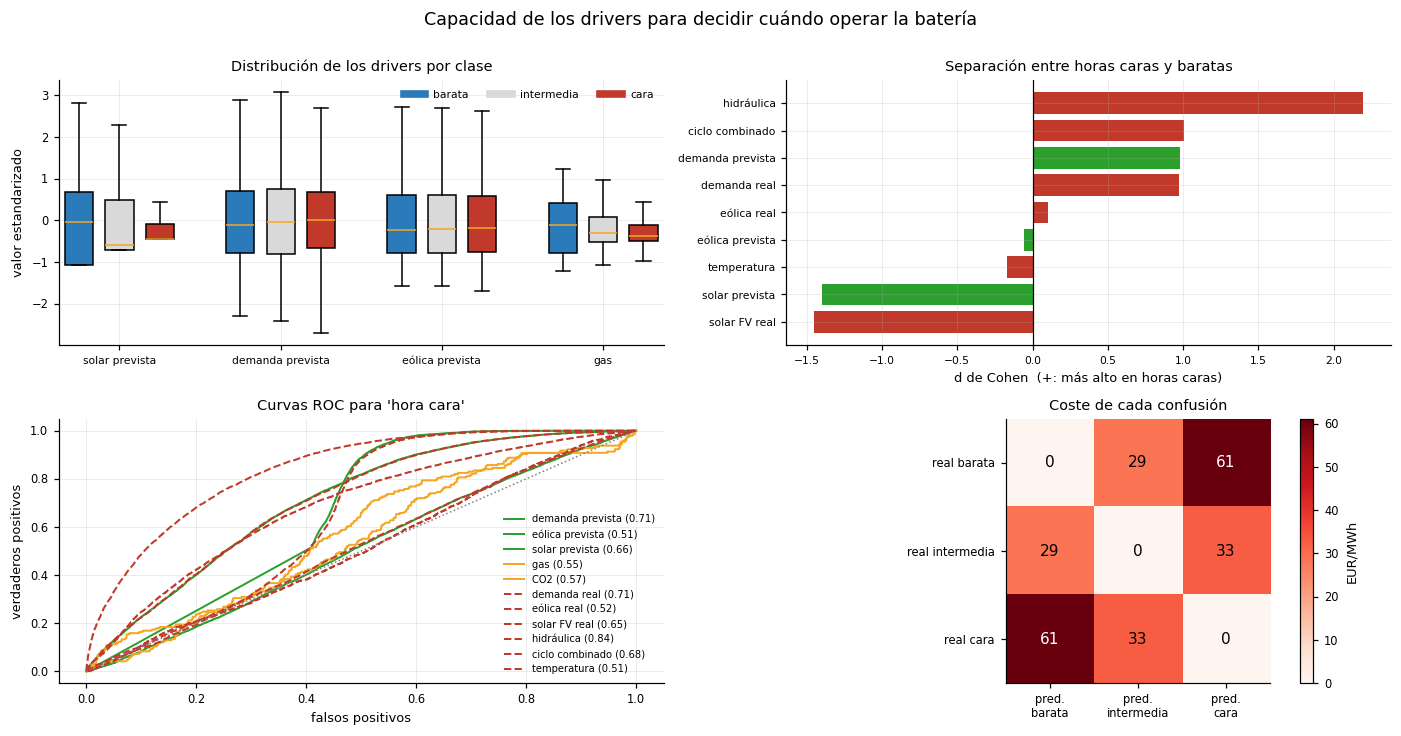

In [9]:
_orden = ["barata", "intermedia", "cara"]
_colcl = {"barata": PALETA["secundario"], "intermedia": PALETA["suave"], "cara": PALETA["alerta"]}

def _cohen(k):
    c = D[k][0]
    a = CL.loc[CL["clase"] == "cara", c].dropna()
    b = CL.loc[CL["clase"] == "barata", c].dropna()
    if len(a) < 100 or len(b) < 100:
        return np.nan
    s = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / s if s else np.nan

def p21(ax):
    ks = [k for k in ("solar prevista", "demanda prevista", "eólica prevista", "gas") if k in D]
    pos = 0; ticks = []
    for k in ks:
        for i, cl_ in enumerate(_orden):
            v = CL.loc[CL["clase"] == cl_, D[k][0]].dropna()
            v = (v - v.mean()) / v.std()          # estandarizado: escalas muy distintas
            bp = ax.boxplot([v], positions=[pos], widths=0.7, showfliers=False,
                            patch_artist=True)
            bp["boxes"][0].set_facecolor(_colcl[cl_])
            pos += 1
        ticks.append((pos - 2, k)); pos += 1
    ax.set_xticks([t for t, _ in ticks], [n for _, n in ticks], fontsize=7)
    ax.set_ylabel("valor estandarizado")
    ax.legend(handles=[Line2D([0], [0], color=v, lw=5, label=k) for k, v in _colcl.items()],
              frameon=False, fontsize=7, ncol=3)

def p22(ax):
    S = pd.Series({k: _cohen(k) for k in D}).dropna().sort_values()
    ax.barh(S.index, S.values,
            color=[COLOR_FUGA.get(D[k][1], PALETA["neutro"]) for k in S.index])
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("d de Cohen  (+: más alto en horas caras)"); ax.tick_params(labelsize=7)

def p23(ax):
    from sklearn.metrics import roc_auc_score, roc_curve
    for k, (c, f) in D.items():
        m = CL[c].notna()
        if m.sum() < 500:
            continue
        auc = roc_auc_score(CL.loc[m, "es_cara"], CL.loc[m, c])
        score = CL.loc[m, c] if auc >= 0.5 else -CL.loc[m, c]
        fpr, tpr, _ = roc_curve(CL.loc[m, "es_cara"], score)
        ax.plot(fpr, tpr, "-" if f != "CON FUGA" else "--", lw=1.3,
                color=COLOR_FUGA.get(f, PALETA["neutro"]),
                label=f"{k} ({max(auc, 1 - auc):.2f})")
    ax.plot([0, 1], [0, 1], ls=":", color=PALETA["neutro"], lw=1)
    ax.set_xlabel("falsos positivos"); ax.set_ylabel("verdaderos positivos")
    ax.legend(frameon=False, fontsize=6.5, loc="lower right")

def p24(ax):
    med = CL.groupby("clase")[P].mean()
    M = pd.DataFrame([[abs(med[a] - med[b]) for b in _orden] for a in _orden],
                     index=_orden, columns=_orden)
    im = ax.imshow(M.values, cmap="Reds")
    ax.set_xticks(range(3), [f"pred.\n{c}" for c in _orden], fontsize=7.5)
    ax.set_yticks(range(3), [f"real {c}" for c in _orden], fontsize=7.5)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{M.iloc[i, j]:.0f}", ha="center", va="center", fontsize=10,
                    color="white" if M.iloc[i, j] > M.values.max() * 0.6 else "black")
    sin_rejilla(ax); plt.colorbar(im, ax=ax, label="EUR/MWh")

lamina("L06_discriminacion", "Capacidad de los drivers para decidir cuándo operar la batería",
       "Evaluación de los drivers como clasificadores de horas caras y baratas, que es la "
       "decisión que toma un sistema de almacenamiento. La matriz de coste traduce el error a "
       "euros: confundir una hora cara con una barata cuesta el diferencial entero, y una "
       "métrica simétrica como el MAE no lo recoge.",
       [("Distribución de los drivers por clase", p21),
        ("Separación entre horas caras y baratas", p22),
        ("Curvas ROC para 'hora cara'", p23),
        ("Coste de cada confusión", p24)])

---
# Lámina 7 · ¿Cómo de buenas son las entradas disponibles?

**Paneles 25-28.** Las features sin fuga son **previsiones**, y una previsión trae su propio
error. Si la eólica de REE se equivoca cientos de MW y además sobreestima de forma sistemática,
el modelo hereda ese error entero: ningún algoritmo recupera información que la entrada no
tiene.

El sesgo es la parte accionable: un sesgo constante se corrige antes de entrenar, el ruido no.

  L07_calidad_previsiones  L07_calidad_previsiones.png


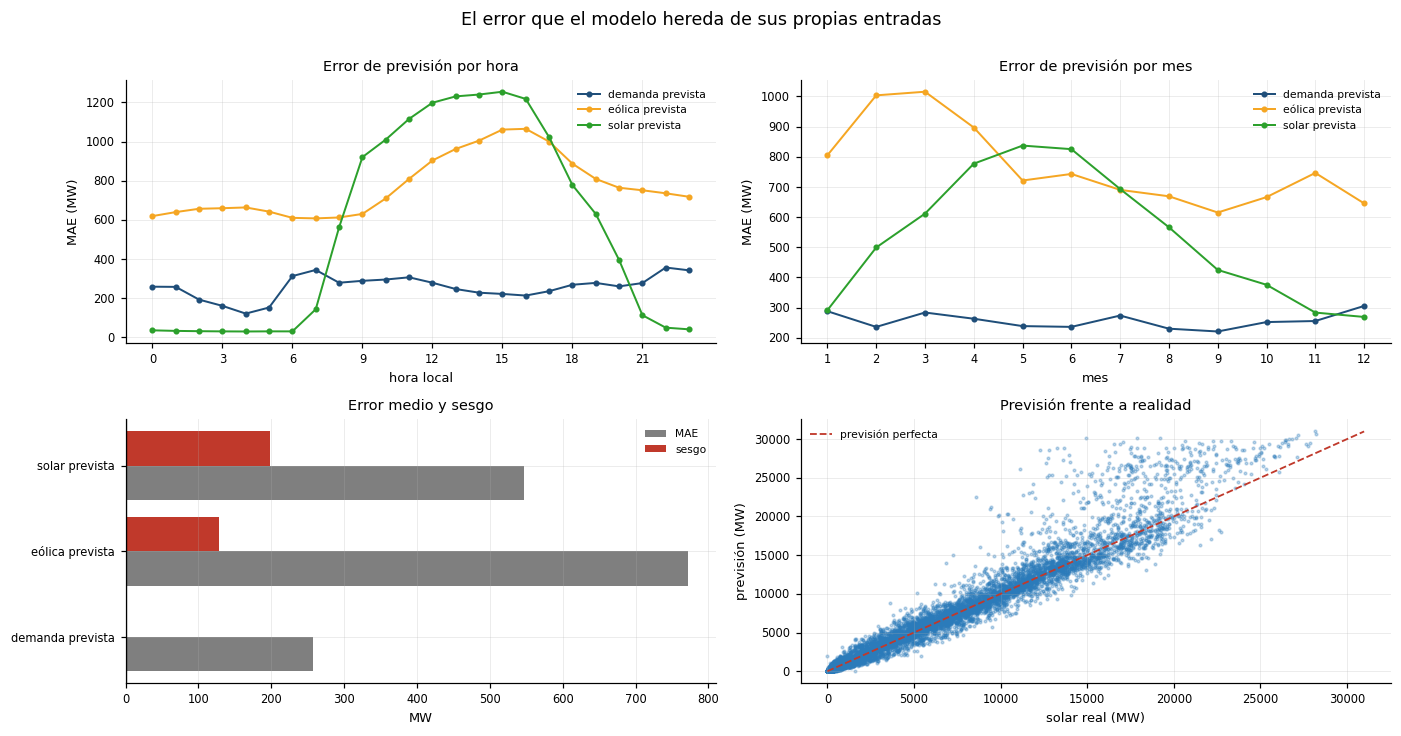

In [10]:
PARES = [(k, D[k][0], real) for k, real in
         [("demanda prevista", DEM), ("eólica prevista", EOL), ("solar prevista", FV)]
         if k in D and real]

def p25(ax):
    for k, cp, cr in PARES:
        d = df[["hora", cp, cr]].dropna()
        ax.plot(d.groupby("hora").apply(lambda g: (g[cp] - g[cr]).abs().mean(),
                                        include_groups=False),
                marker="o", ms=3, lw=1.3, label=k)
    ax.set_xlabel("hora local"); ax.set_ylabel("MAE (MW)")
    ax.set_xticks(range(0, 24, 3)); ax.legend(frameon=False, fontsize=7)

def p26(ax):
    for k, cp, cr in PARES:
        d = df[["mes", cp, cr]].dropna()
        ax.plot(d.groupby("mes").apply(lambda g: (g[cp] - g[cr]).abs().mean(),
                                       include_groups=False),
                marker="o", ms=3, lw=1.3, label=k)
    ax.set_xlabel("mes"); ax.set_ylabel("MAE (MW)")
    ax.set_xticks(range(1, 13)); ax.legend(frameon=False, fontsize=7)

def p27(ax):
    filas = []
    for k, cp, cr in PARES:
        d = df[[cp, cr]].dropna()
        e = d[cp] - d[cr]
        filas.append({"variable": k, "MAE": e.abs().mean(), "sesgo": e.mean()})
    S = pd.DataFrame(filas).set_index("variable")
    y = np.arange(len(S))
    ax.barh(y - 0.2, S["MAE"], height=0.4, color=PALETA["neutro"], label="MAE")
    ax.barh(y + 0.2, S["sesgo"], height=0.4, color=PALETA["alerta"], label="sesgo")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_yticks(y, S.index, fontsize=7.5); ax.set_xlabel("MW")
    ax.legend(frameon=False, fontsize=7)

def p28(ax):
    if not PARES:
        raise ValueError("sin pares previsión-real")
    k, cp, cr = PARES[-1]
    d = df[[cp, cr]].dropna().sample(min(15000, len(df)), random_state=0)
    ax.scatter(d[cr], d[cp], s=3, alpha=0.3, color=PALETA["secundario"])
    lim = [0, max(d[cr].max(), d[cp].max())]
    ax.plot(lim, lim, color=PALETA["alerta"], lw=1.2, ls="--", label="previsión perfecta")
    ax.set_xlabel(f"{k.replace(' prevista', '')} real (MW)")
    ax.set_ylabel("previsión (MW)"); ax.legend(frameon=False, fontsize=7)

lamina("L07_calidad_previsiones", "El error que el modelo hereda de sus propias entradas",
       "Las únicas variables disponibles a las 12:00 de D son previsiones, y su error marca un "
       "suelo que ningún algoritmo puede rebasar. El panel del sesgo separa la parte corregible "
       "—un desvío sistemático se descuenta antes de entrenar— de la parte que es ruido puro.",
       [("Error de previsión por hora", p25), ("Error de previsión por mes", p26),
        ("Error medio y sesgo", p27), ("Previsión frente a realidad", p28)])

---
# Lámina 8 · ¿Son fiables los datos de partida?

**Paneles 29-32.** La parte de calidad, resumida en una página. Lo importante no es la lista de
nulos sino **distinguir el hueco estructural del hueco real**: un 95,8 % de nulos en una tabla
diaria es 23 de cada 24 horas por diseño, no una base agujereada.

El patrón de ausencias lo demuestra formalmente, y el panel del DST verifica que los días de 23
y 25 horas son exactamente los cambios de horario.

  L08_calidad_datos  L08_calidad_datos.png


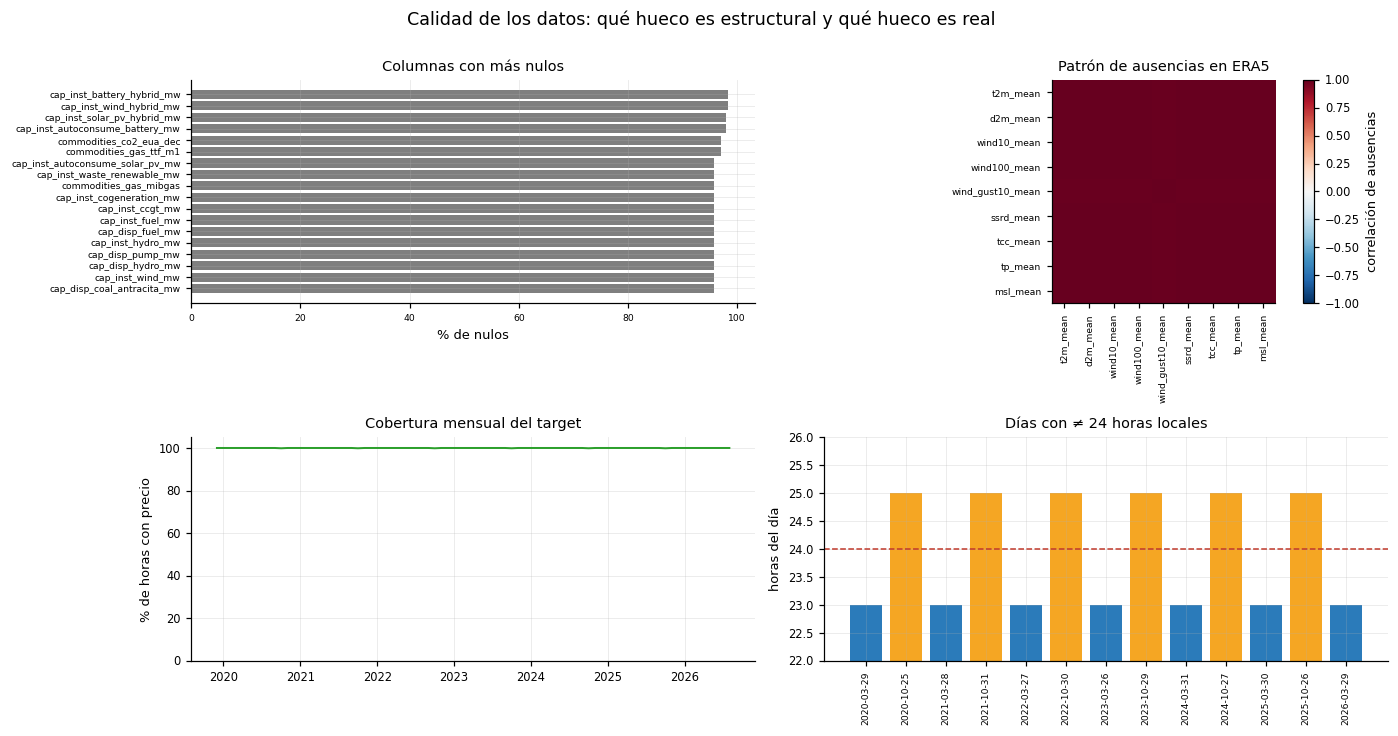

In [11]:
def p29(ax):
    n = df.isna().mean().mul(100)
    n = n[n > 0].sort_values(ascending=False).head(18)
    ax.barh(n.index[::-1], n.values[::-1], color=PALETA["neutro"])
    ax.set_xlabel("% de nulos"); ax.tick_params(labelsize=6)

def p30(ax):
    cs = [c for c in df.columns if c.startswith("era5_")]
    if len(cs) < 2:
        raise ValueError("sin columnas era5")
    im = ax.imshow(df[cs].isna().corr().values, cmap=CMAP_DIV, vmin=-1, vmax=1)
    ax.set_xticks(range(len(cs)), [c[5:22] for c in cs], rotation=90, fontsize=6)
    ax.set_yticks(range(len(cs)), [c[5:22] for c in cs], fontsize=6)
    sin_rejilla(ax); plt.colorbar(im, ax=ax, label="correlación de ausencias")

def p31(ax):
    cob = df.set_index("ts_utc")[[P]].notna().resample("MS").mean().mul(100)
    ax.plot(cob.index, cob.values, lw=1.3, color=PALETA["ok"])
    ax.set_ylim(0, 105); ax.set_ylabel("% de horas con precio"); ax.set_xlabel("")

def p32(ax):
    hd = df.groupby("dia").size()
    at = hd[hd != 24]
    if len(at) == 0:
        raise ValueError("ningún día con != 24 horas")
    ax.bar(range(len(at)), at.values,
           color=[PALETA["secundario"] if v == 23 else PALETA["acento"] for v in at.values])
    ax.axhline(24, color=PALETA["alerta"], ls="--", lw=1)
    ax.set_xticks(range(len(at)), [str(i) for i in at.index], rotation=90, fontsize=6)
    ax.set_ylabel("horas del día"); ax.set_ylim(22, 26)

lamina("L08_calidad_datos", "Calidad de los datos: qué hueco es estructural y qué hueco es real",
       "Los nulos elevados de las tablas diarias y de ERA5 son consecuencia del diseño de la "
       "unión, no huecos de datos: el patrón de ausencias lo demuestra al mostrar bloques "
       "uniformes. Los días con 23 y 25 horas corresponden exactamente a los cambios de "
       "horario, lo que valida cualquier agregación diaria posterior.",
       [("Columnas con más nulos", p29), ("Patrón de ausencias en ERA5", p30),
        ("Cobertura mensual del target", p31), ("Días con ≠ 24 horas locales", p32)])

---
# Lámina 9 · ¿Qué fuente se elige cuando hay dos?

**Paneles 33-36.** Varias magnitudes están medidas por dos organismos, y no siempre coinciden.
Esta lámina reúne las cuatro decisiones de fuente que condicionan qué columna entra al modelo.

El caso del autoconsumo es el más claro: dos series rompen **el mismo mes con la misma
magnitud**, lo que prueba que es un solo fenómeno entrando por los dos lados del balance.

  L09_decisiones_fuente  L09_decisiones_fuente.png


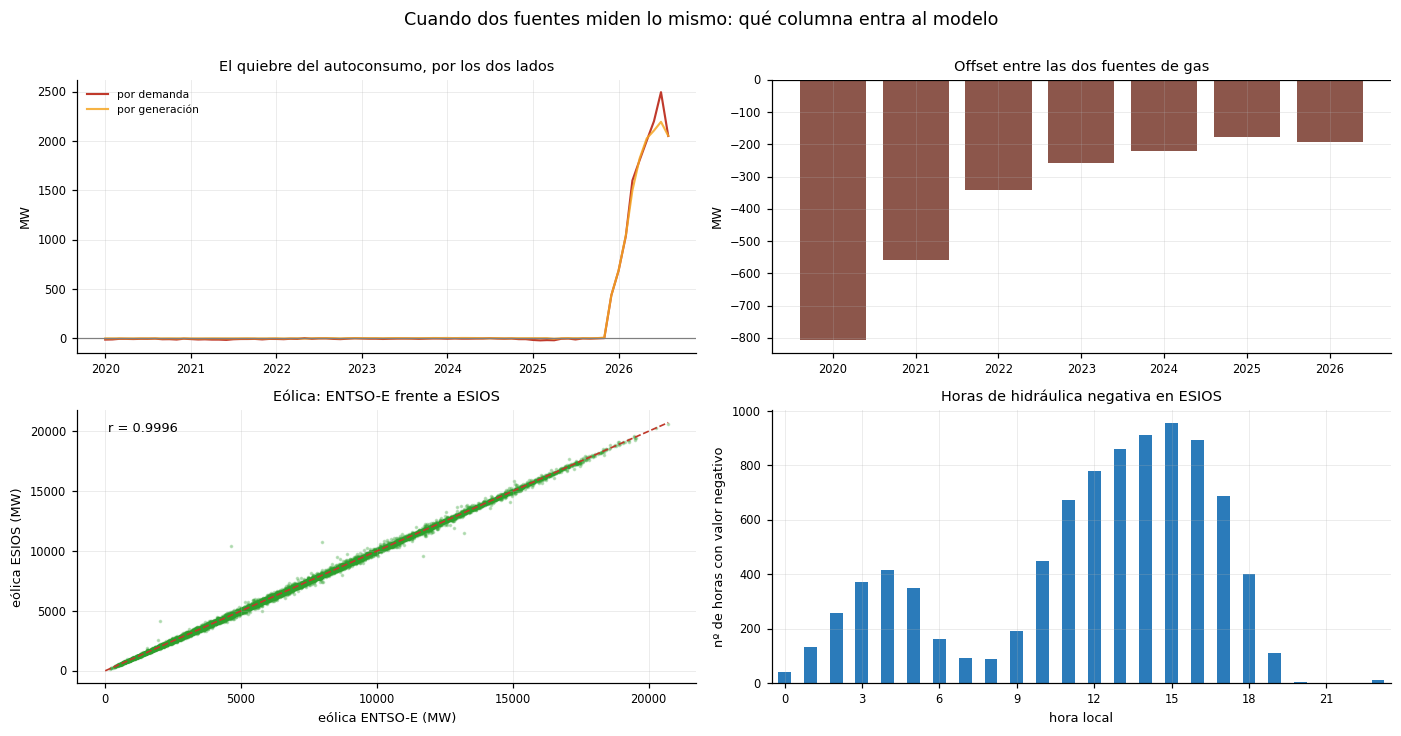

In [12]:
AUTO = pick(df, "calc_autoconsumo_mw")
SOLREE = pick(df, "esios_gen_ree_gsolar_mw")
GASENT = pick(df, "entsoe_gas_mw")
CCGT = pick(df, "esios_gen_ree_gccgas_mw")
OTHER = pick(df, "esios_gen_ree_gotherthermal_mw")
WREE = pick(df, "esios_gen_ree_gwind_mw")
HREE = pick(df, "esios_gen_ree_ghidro_mw")

def p33(ax):
    if not AUTO:
        raise ValueError("sin calc_autoconsumo_mw")
    s = df.groupby("mes_p")[AUTO].mean()
    ax.plot(s.index.to_timestamp(), s.values, lw=1.4, color=PALETA["alerta"],
            label="por demanda")
    if SOLREE and FV:
        d = df[["mes_p", SOLREE, FV]].dropna()
        dif = (d[SOLREE] - d[FV]).groupby(d["mes_p"]).mean()
        ax.plot(dif.index.to_timestamp(), dif.values, lw=1.4, color=PALETA["acento"],
                alpha=0.85, label="por generación")
    ax.axhline(0, color=PALETA["neutro"], lw=0.8)
    ax.set_ylabel("MW"); ax.set_xlabel(""); ax.legend(frameon=False, fontsize=7)

def p34(ax):
    if not all([GASENT, CCGT, OTHER]):
        raise ValueError("faltan columnas de gas")
    d = df[["anio", GASENT, CCGT, OTHER]].dropna()
    off = (d.groupby("anio")[GASENT].mean()
           - d.groupby("anio").apply(lambda g: (g[CCGT] + g[OTHER]).mean(),
                                     include_groups=False))
    ax.bar(off.index.astype(str), off.values, color="#8c564b")
    ax.axhline(0, color="black", lw=0.8); ax.set_ylabel("MW"); ax.set_xlabel("")

def p35(ax):
    if not (EOL and WREE):
        raise ValueError("faltan las dos fuentes de eólica")
    d = df[[EOL, WREE]].dropna().sample(min(15000, len(df)), random_state=0)
    ax.scatter(d[EOL], d[WREE], s=2, alpha=0.25, color=PALETA["ok"])
    lim = [0, d.max().max()]
    ax.plot(lim, lim, color=PALETA["alerta"], lw=1.1, ls="--")
    r = df[EOL].corr(df[WREE])
    ax.set_xlabel("eólica ENTSO-E (MW)"); ax.set_ylabel("eólica ESIOS (MW)")
    ax.text(0.05, 0.92, f"r = {r:.4f}", transform=ax.transAxes, fontsize=8.5)

def p36(ax):
    if not HREE:
        raise ValueError("sin esios_gen_ree_ghidro_mw")
    neg = df[df[HREE] < 0]
    if len(neg) == 0:
        raise ValueError("sin valores negativos")
    neg["hora"].value_counts().sort_index().reindex(range(24), fill_value=0).plot(
        kind="bar", ax=ax, color=PALETA["secundario"])
    ax.set_xticks(range(0, 24, 3), range(0, 24, 3), rotation=0)
    ax.set_xlabel("hora local"); ax.set_ylabel("nº de horas con valor negativo")

lamina("L09_decisiones_fuente", "Cuando dos fuentes miden lo mismo: qué columna entra al modelo",
       "Cuatro decisiones de fuente con su evidencia. El autoconsumo rompe las series de ESIOS "
       "por demanda y por generación el mismo mes y con la misma magnitud. El agregado de gas "
       "de ENTSO-E mezcla dos tecnologías con un desfase que no es estable. La eólica sí es "
       "intercambiable entre fuentes. Y la hidráulica de ESIOS mezcla generación con bombeo, "
       "como delata su concentración de valores negativos al mediodía.",
       [("El quiebre del autoconsumo, por los dos lados", p33),
        ("Offset entre las dos fuentes de gas", p34),
        ("Eólica: ENTSO-E frente a ESIOS", p35),
        ("Horas de hidráulica negativa en ESIOS", p36)])

---
# Lámina 10 · ¿Contra qué se compara el modelo?

**Paneles 37-40.** La lámina que cierra. Si una regla tan simple como «descarga siempre a las
mismas horas» ya captura una parte grande del arbitraje posible, **eso es el listón**: el margen
restante es todo lo que un modelo puede aportar.

Es también el argumento de por qué el MAE no basta como métrica, y enlaza directamente con la
evaluación económica de los baselines.

  L10_vara_referencia  L10_vara_referencia.png


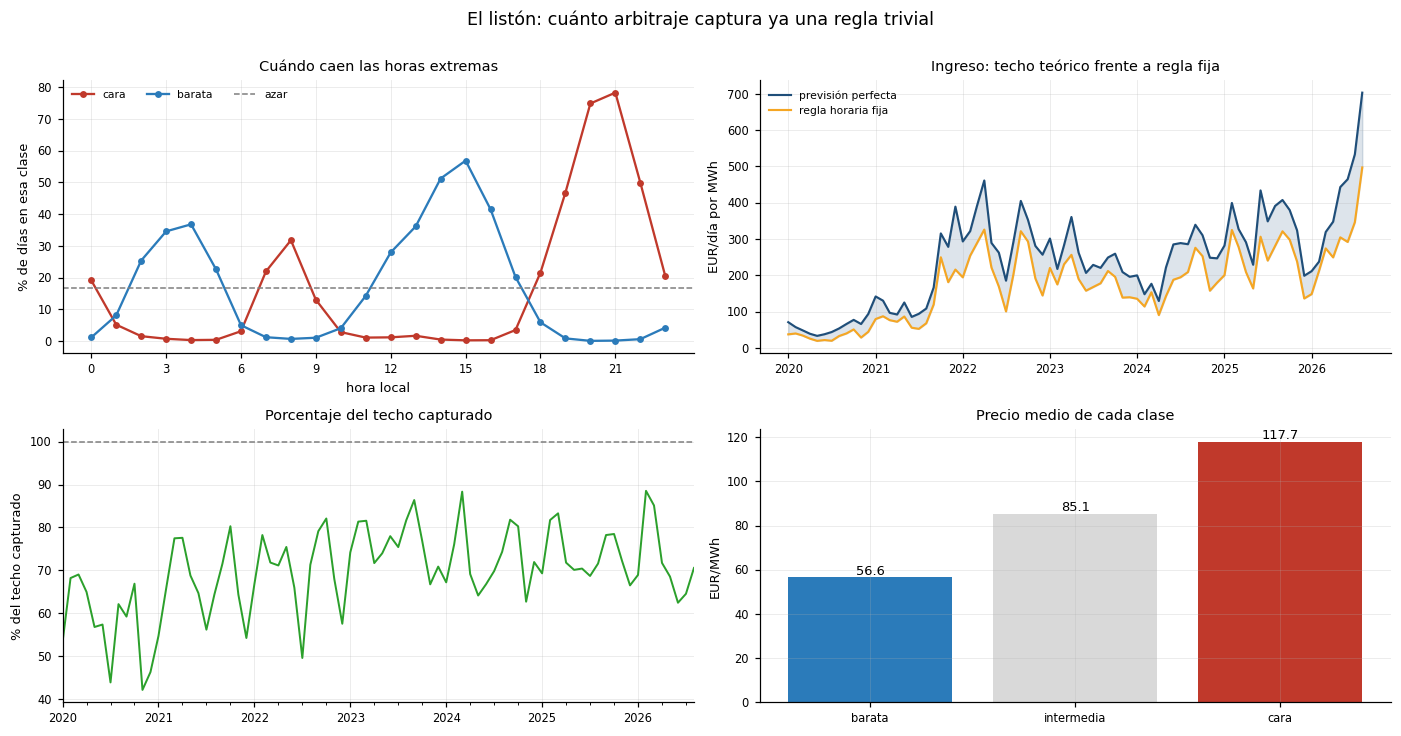

In [13]:
_tab = pd.crosstab(CL["hora"], CL["clase"], normalize="index") * 100
_mejores = _tab["cara"].nlargest(K).index.tolist()
_peores = _tab["barata"].nlargest(K).index.tolist()

def p37(ax):
    ax.plot(_tab.index, _tab["cara"], marker="o", ms=3.5, lw=1.5,
            color=PALETA["alerta"], label="cara")
    ax.plot(_tab.index, _tab["barata"], marker="o", ms=3.5, lw=1.5,
            color=PALETA["secundario"], label="barata")
    ax.axhline(100 * K / 24, color=PALETA["neutro"], ls="--", lw=1, label="azar")
    ax.set_xlabel("hora local"); ax.set_ylabel("% de días en esa clase")
    ax.set_xticks(range(0, 24, 3)); ax.legend(frameon=False, fontsize=7, ncol=3)

def _ingresos():
    filas = []
    for dia, g in CL.groupby("dia"):
        if len(g) < 20:
            continue
        perf = g.nlargest(K, P)[P].sum() - g.nsmallest(K, P)[P].sum()
        c_ = g[g["hora"].isin(_peores)].head(K)
        v_ = g[g["hora"].isin(_mejores)].head(K)
        if len(c_) < K or len(v_) < K:
            continue
        filas.append({"dia": dia, "perfecto": perf, "regla": v_[P].sum() - c_[P].sum()})
    E = pd.DataFrame(filas).set_index("dia")
    E.index = pd.to_datetime(E.index)
    return E

_E = _ingresos()

def p38(ax):
    m = _E.resample("MS").mean()
    ax.plot(m.index, m["perfecto"], lw=1.4, color=PALETA["principal"], label="previsión perfecta")
    ax.plot(m.index, m["regla"], lw=1.4, color=PALETA["acento"], label="regla horaria fija")
    ax.fill_between(m.index, m["regla"], m["perfecto"], alpha=0.15, color=PALETA["principal"])
    ax.set_ylabel("EUR/día por MWh"); ax.set_xlabel("")
    ax.legend(frameon=False, fontsize=7)

def p39(ax):
    pct = (_E["regla"] / _E["perfecto"].replace(0, np.nan) * 100).clip(-20, 120)
    pct.resample("MS").mean().plot(ax=ax, lw=1.3, color=PALETA["ok"])
    ax.axhline(100, color=PALETA["neutro"], ls="--", lw=1)
    ax.set_ylabel("% del techo capturado"); ax.set_xlabel("")

def p40(ax):
    med = CL.groupby("clase")[P].mean().reindex(_orden)
    ax.bar(_orden, med.values, color=[_colcl[c] for c in _orden])
    for i, v in enumerate(med.values):
        ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8.5)
    ax.set_ylabel("EUR/MWh")

_pct_total = _E["regla"].sum() / _E["perfecto"].sum() * 100
lamina("L10_vara_referencia", "El listón: cuánto arbitraje captura ya una regla trivial",
       f"Una regla fija —descargar y cargar siempre a las mismas horas— captura el "
       f"{_pct_total:.1f} % del arbitraje máximo teórico. El margen restante es todo lo que un "
       f"modelo puede aportar, y la referencia contra la que debe evaluarse. Es también el "
       f"motivo de medir el rendimiento en euros y no sólo en error medio.",
       [("Cuándo caen las horas extremas", p37),
        ("Ingreso: techo teórico frente a regla fija", p38),
        ("Porcentaje del techo capturado", p39),
        ("Precio medio de cada clase", p40)])

---
# Cierre · pies de lámina y paneles sueltos

La primera celda escribe los pies para pegar bajo cada lámina en la memoria. La segunda es
opcional: exporta paneles individuales por si alguno acaba mereciendo página propia o se
necesita en la presentación de la defensa.

In [14]:
ruta = SALIDA / "pies_de_lamina.md"
with ruta.open("w", encoding="utf-8") as f:
    f.write("# Pies de lámina\n\n")
    f.write("*Generado por `12_laminas_tfm.ipynb`. No editar a mano: se regenera.*\n\n")
    for i, (etq, fichero, titulo, pie) in enumerate(LAMINAS, start=1):
        f.write(f"## Lámina {i} — `{fichero}`\n\n**{titulo}**\n\n{pie}\n\n")

print(f"{len(LAMINAS)} láminas · {len(PANELES_OK)} paneles correctos de 40")
fallidos = 40 - len(PANELES_OK)
if fallidos:
    print(f"{fallidos} paneles no se pudieron dibujar: revisar los avisos en cada lámina.")
print(f"\nPies: {ruta}")

10 láminas · 40 paneles correctos de 40

Pies: c:\Users\torgi\proyectos\tfm-energia\docs\figuras\pies_de_lamina.md


In [15]:
# Opcional: exportar paneles sueltos. Descomentar los que interesen.
# panel_suelto("p05_perfil_horario_anio", p05)
# panel_suelto("p13_curva_oferta", p13)
# panel_suelto("p17_ranking_fuga", p17)
# panel_suelto("p38_arbitraje", p38)
print(f"Para exportar un panel por separado: panel_suelto('nombre', pXX)")
print(f"Se guardan en {SUELTOS}")

Para exportar un panel por separado: panel_suelto('nombre', pXX)
Se guardan en c:\Users\torgi\proyectos\tfm-energia\docs\figuras\paneles
